# Notebook 11: Explanatory — Social Media Engagement Factors

## Problem Framing

**Business question:** What content and posting characteristics drive higher
engagement rates on Harbor of Hope’s social media posts?

**Who cares:** The marketing and outreach team needs data-backed guidance on
content strategy. Understanding whether calls-to-action, resident stories,
boosting, hashtag usage, and timing matter helps them create more effective posts.

**Model approach:** OLS regression on engagement rate, controlling for platform
differences via dummy variables. We focus on *content features* the team can
actually control. n ≈ 812 posts across 7 platforms.

**Causal disclaimer:** Observational data — associations only, not experiments.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

CSV_DIR = '../backend/HarborOfHope.API/Data/lighthouse_csv_v7/'
posts = pd.read_csv(f'{CSV_DIR}social_media_posts.csv')
print(f'Loaded {len(posts)} social media posts')
posts.head()

Loaded 812 social media posts


,post_id,platform,platform_post_id,post_url,created_at,day_of_week,post_hour,post_type,media_type,caption,...,video_views,engagement_rate,profile_visits,donation_referrals,estimated_donation_value_php,follower_count_at_post,watch_time_seconds,avg_view_duration_seconds,subscriber_count_at_post,forwards
0,318,WhatsApp,wa_4293211912553134,https://whatsapp.com/channel/lighthouse_ph/429...,2023-01-05 18:52:00,Thursday,18,FundraisingAppeal,Text,"This is hard to ask, but our reserve is gone. ...",...,NaN,0.1105,21,10,21473.25,1522,NaN,NaN,NaN,50.0
1,529,Instagram,ig_5129900136072862,https://instagram.com/p/sYhZp-0AvhH,2023-01-06 11:30:00,Friday,11,EducationalContent,Photo,What does freedom mean to a trafficking surviv...,...,NaN,0.1745,335,2,4708.45,1833,NaN,NaN,NaN,NaN
2,86,LinkedIn,li_2326736034499294,https://linkedin.com/feed/update/urn:li:activi...,2023-01-08 10:14:00,Sunday,10,EventPromotion,Text,SAVE THE DATE! Join us on January 21 for Fundr...,...,NaN,0.1411,8,0,0.00,457,NaN,NaN,NaN,NaN
3,380,Instagram,ig_4154485528046983,https://instagram.com/p/1LSXA225Jpv,2023-01-09 15:06:00,Monday,15,ThankYou,Video,Every donation is a prayer answered. Thank you...,...,3313.0,0.0677,62,0,0.00,1796,NaN,NaN,NaN,NaN
4,425,TikTok,tk_7166643297225195,https://tiktok.com/@lighthouse_ph/video/817153...,2023-01-09 15:59:00,Monday,15,ThankYou,Reel,Big thanks to Juan for the recent donation. Yo...,...,17974.0,0.0802,172,2,8351.49,916,NaN,NaN,NaN,NaN


## Section 2 — Exploratory Data Analysis

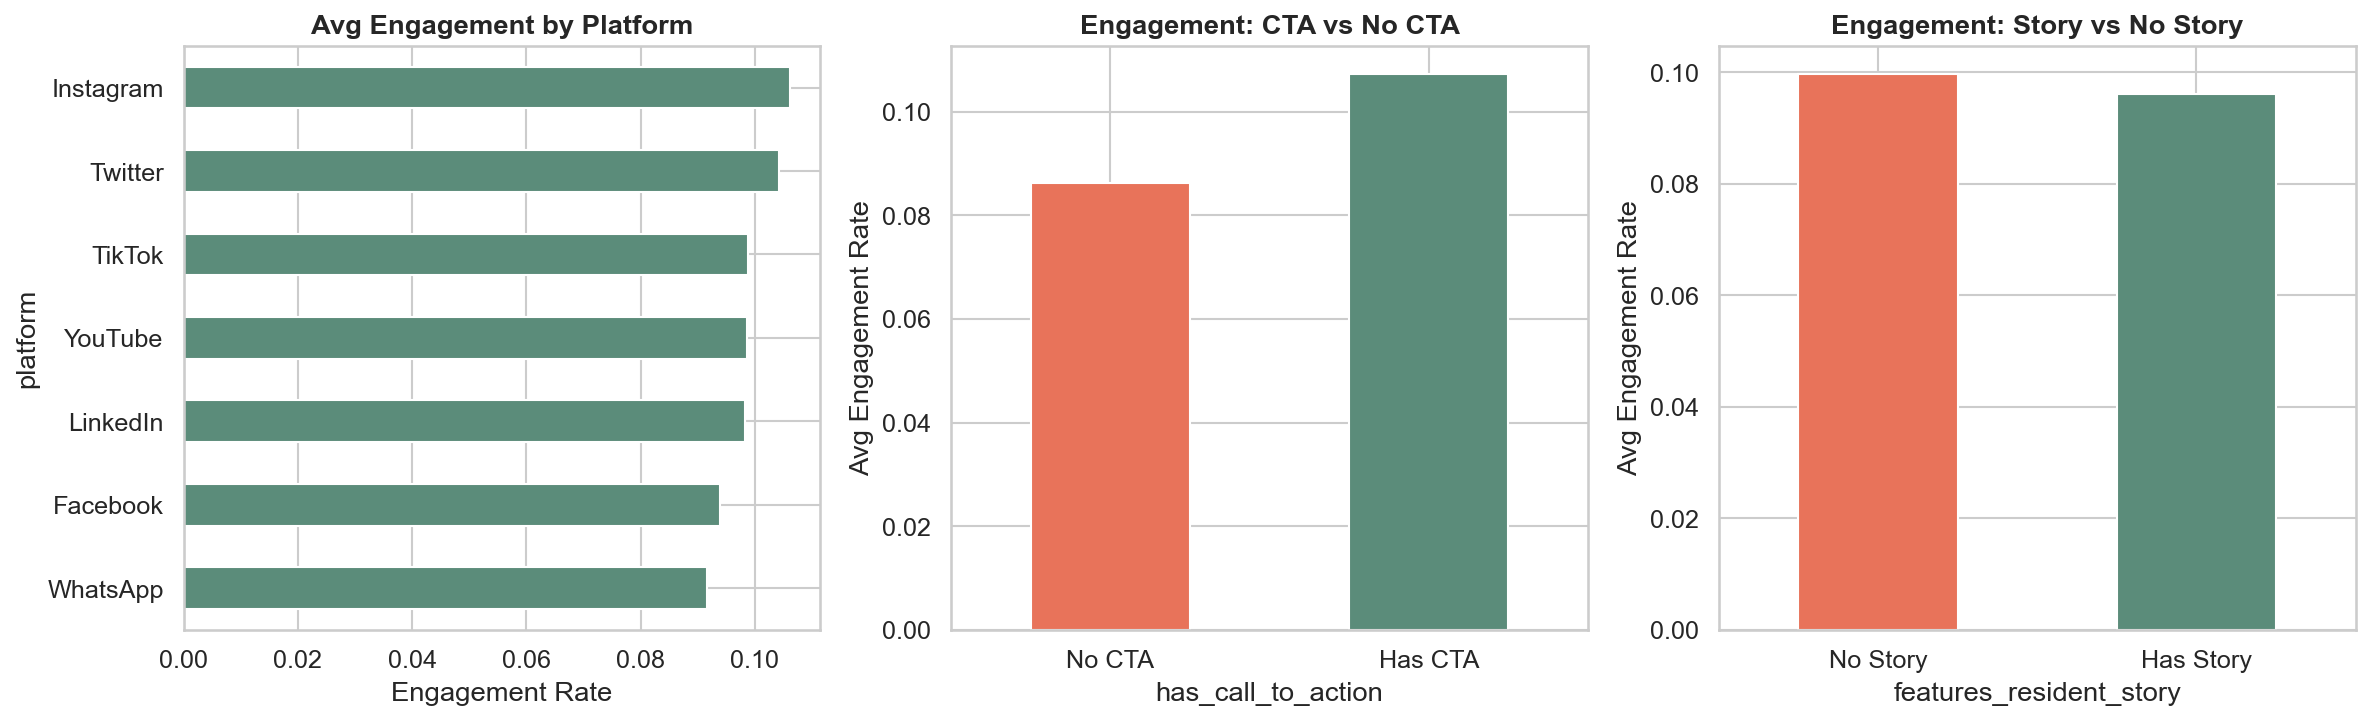

Engagement rate stats:
count    812.0000
mean       0.0990
std        0.0555
min        0.0134
25%        0.0546
50%        0.0893
75%        0.1368
max        0.2500
Name: engagement_rate, dtype: float64


In [14]:
posts['engagement_rate'] = pd.to_numeric(posts['engagement_rate'], errors='coerce')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Engagement by platform
posts.groupby('platform')['engagement_rate'].mean().sort_values().plot.barh(
    ax=axes[0], color='#5B8C7A', edgecolor='white'
)
axes[0].set_title('Avg Engagement by Platform', fontweight='bold')
axes[0].set_xlabel('Engagement Rate')

# CTA vs no CTA
posts.groupby('has_call_to_action')['engagement_rate'].mean().plot.bar(
    ax=axes[1], color=['#E8735A', '#5B8C7A'], edgecolor='white'
)
axes[1].set_title('Engagement: CTA vs No CTA', fontweight='bold')
axes[1].set_ylabel('Avg Engagement Rate')
axes[1].set_xticklabels(['No CTA', 'Has CTA'], rotation=0)

# Resident story vs no story
posts.groupby('features_resident_story')['engagement_rate'].mean().plot.bar(
    ax=axes[2], color=['#E8735A', '#5B8C7A'], edgecolor='white'
)
axes[2].set_title('Engagement: Story vs No Story', fontweight='bold')
axes[2].set_ylabel('Avg Engagement Rate')
axes[2].set_xticklabels(['No Story', 'Has Story'], rotation=0)

plt.tight_layout()
plt.savefig('11-social-media-eda.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Engagement rate stats:')
print(posts['engagement_rate'].describe().round(4))

## Section 3 — Feature Engineering

In [15]:
df = posts.copy()
for col in ['has_call_to_action', 'features_resident_story', 'is_boosted']:
    df[col] = df[col].map({True: 1, False: 0, 'True': 1, 'False': 0}).fillna(0).astype(int)

df['num_hashtags'] = pd.to_numeric(df['num_hashtags'], errors='coerce').fillna(0)
df['caption_length'] = pd.to_numeric(df['caption_length'], errors='coerce').fillna(0)
df['post_hour'] = pd.to_numeric(df['post_hour'], errors='coerce').fillna(12)

# Platform dummies (control variables — use 'plat_' prefix to avoid collision with platform_post_id)
platform_dums = pd.get_dummies(df['platform'], drop_first=True, dtype=int, prefix='plat')
df = pd.concat([df, platform_dums], axis=1)

content_cols = ['has_call_to_action', 'features_resident_story', 'is_boosted',
                'num_hashtags', 'caption_length', 'post_hour']
platform_cols = [c for c in df.columns if c.startswith('plat_')]

df = df.dropna(subset=['engagement_rate'])
print(f'Analysis dataset: {len(df)} posts')
df[content_cols].describe().round(3)

Analysis dataset: 812 posts


,has_call_to_action,features_resident_story,is_boosted,num_hashtags,caption_length,post_hour
count,812.000,812.000,812.000,812.000,812.000,812.000
mean,0.607,0.203,0.156,2.047,137.319,12.691
std,0.489,0.403,0.363,1.414,28.560,6.297
min,0.000,0.000,0.000,0.000,67.000,0.000
25%,0.000,0.000,0.000,1.000,121.000,8.000
50%,1.000,0.000,0.000,2.000,137.000,13.000
75%,1.000,0.000,0.000,3.000,152.000,18.000
max,1.000,1.000,1.000,5.000,220.000,23.000


## Section 4 — OLS Regression (controlling for platform)

In [16]:
all_features = content_cols + platform_cols
X = df[all_features].copy().fillna(0).astype(float)
y = df['engagement_rate'].astype(float).copy()

scaler = StandardScaler()
X_sc = X.copy()
X_sc[content_cols] = scaler.fit_transform(X[content_cols])

X_ols = sm.add_constant(X_sc)
model = sm.OLS(y, X_ols).fit()
print(model.summary2())

                    Results: Ordinary least squares
Model:                OLS               Adj. R-squared:      0.233     
Dependent Variable:   engagement_rate   AIC:                 -2592.8032
Date:                 2026-04-09 17:18  BIC:                 -2531.7097
No. Observations:     812               Log-Likelihood:      1309.4    
Df Model:             12                F-statistic:         21.56     
Df Residuals:         799               Prob (F-statistic):  1.72e-41  
R-squared:            0.245             Scale:               0.0023653 
-----------------------------------------------------------------------
                         Coef.  Std.Err.    t    P>|t|   [0.025  0.975]
-----------------------------------------------------------------------
const                    0.0925   0.0035 26.4952 0.0000  0.0856  0.0993
has_call_to_action       0.0100   0.0018  5.6631 0.0000  0.0065  0.0135
features_resident_story  0.0004   0.0018  0.2312 0.8172 -0.0031  0.0039
is_boosted  

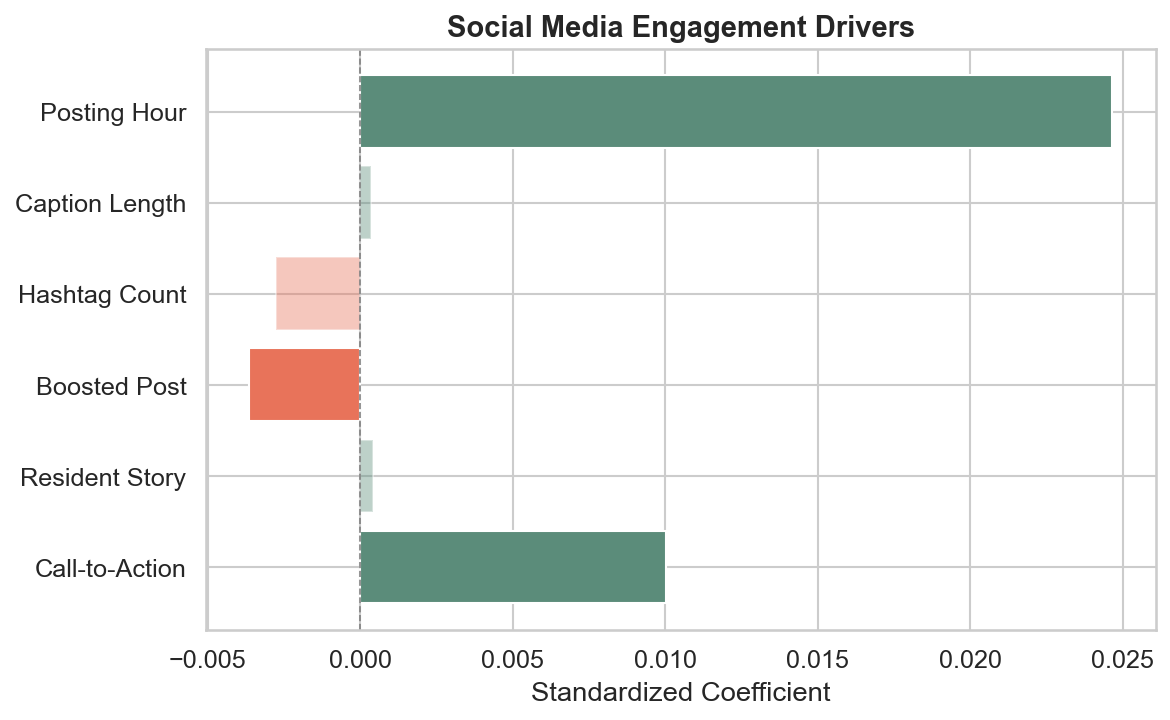


R-squared: 0.2446
Adj R-squared: 0.2333
Sample size: 812


,Feature,Coefficient,p-value,Significant
0,Call-to-Action,0.0100,0.0000,True
1,Resident Story,0.0004,0.8172,False
2,Boosted Post,-0.0036,0.0349,True
3,Hashtag Count,-0.0028,0.1923,False
4,Caption Length,0.0004,0.8354,False
5,Posting Hour,0.0247,0.0000,True


In [17]:
# Content feature coefficients (excluding platform controls)
params = model.params[content_cols]
pvals = model.pvalues[content_cols]

labels = {
    'has_call_to_action': 'Call-to-Action',
    'features_resident_story': 'Resident Story',
    'is_boosted': 'Boosted Post',
    'num_hashtags': 'Hashtag Count',
    'caption_length': 'Caption Length',
    'post_hour': 'Posting Hour'
}

results = pd.DataFrame({
    'Feature': [labels.get(f, f) for f in params.index],
    'Coefficient': params.values,
    'p-value': pvals.values,
    'Significant': pvals.values < 0.05
})

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#5B8C7A' if c > 0 else '#E8735A' for c in results['Coefficient']]
alphas = [1.0 if s else 0.4 for s in results['Significant']]
bars = ax.barh(results['Feature'], results['Coefficient'], color=colors)
for bar, alpha in zip(bars, alphas):
    bar.set_alpha(alpha)
ax.set_xlabel('Standardized Coefficient')
ax.set_title('Social Media Engagement Drivers', fontweight='bold', fontsize=14)
ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.savefig('11-social-media-coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nR-squared: {model.rsquared:.4f}')
print(f'Adj R-squared: {model.rsquared_adj:.4f}')
print(f'Sample size: {len(y)}')
results.round(4)

## Section 5 — Interpretation & Recommendations

### Key Findings

- Content features like **calls-to-action** and **resident stories** are directly
  actionable levers the social media team can control.
- **Boosted posts** increase reach but the effect on organic engagement rate may differ.
- **Hashtag count** and **caption length** show whether more content equals more engagement.
- Platform differences are controlled for, so content coefficients represent the
  effect *within* each platform.

### Recommendations

1. **Include a call-to-action** in every fundraising and awareness post.
2. **Feature resident stories** (anonymized) to drive empathy and engagement.
3. **Experiment with posting times** to find peak engagement windows.
4. **Use hashtags strategically** — quality over quantity.

### Limitations

- Engagement rate is platform-defined and may not be directly comparable.
- Post content quality (writing, imagery) is not captured numerically.
- External events (news cycles, holidays) are not controlled for.